# Heart Disease Prediction System

End-to-end Machine Learning project to predict the presence of heart disease using patient health data.

**Dataset:** UCI Heart Disease Data (multi-site: Cleveland, Hungary, Switzerland, VA Long Beach) — 920 records, 16 columns.

**Models used:** Logistic Regression, Random Forest, Support Vector Machine (SVM)

**Workflow:** Data Loading → Cleaning → EDA → Preprocessing → Model Training → Evaluation (Accuracy, ROC-AUC, Precision/Recall) → Model Saving → Reload Verification


## Phase 1: Setup & Imports

Importing all the libraries we'll need across the notebook, and setting a consistent, professional plotting style for our charts.

In [99]:
# Core data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


In [100]:
# Scikit-learn: preprocessing, models, evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)


In [101]:
# For saving/loading trained models
import joblib


In [102]:
# For displaying dynamic, formatted markdown-style results inside the notebook
from IPython.display import display, Markdown


In [103]:
# Notebook-wide settings for clean, professional visuals
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

# A consistent, professional color palette used throughout the notebook
PALETTE = ["#2E86AB", "#E63946", "#2A9D8F", "#F4A261", "#8E7DBE"]
sns.set_palette(PALETTE)


## Phase 2: Data Loading & Overview

Loading the dataset and taking a first look at its structure, size, and basic statistics.

In [104]:
# Load the dataset
df = pd.read_csv("../Dataset/heart.csv")


In [105]:
# First 5 rows — quick visual check
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [106]:
# Shape of the dataset (rows, columns)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 920, Columns: 16


In [107]:
# Data types and non-null counts for every column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [108]:
# Statistical summary of numeric columns
df.describe()


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [109]:
# Missing values per column
df.isnull().sum()


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [110]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


**Observation:** This dataset combines patient records from four different sites (see the `dataset` column: Cleveland, Hungary, Switzerland, VA Long Beach). Because of that, several columns — especially `ca` and `thal` — have a noticeable number of missing values, since not every site collected every test. The target column is `num`, ranging from 0 (no disease) to 4 (varying severity) — we'll convert this into a binary target in the cleaning phase.

## Phase 3: Data Cleaning

Steps in this phase:
1. Drop the `id` column (just a row identifier, no predictive value)
2. Convert the multi-class target `num` into a binary `target` (0 = no disease, 1 = disease present)
3. Handle missing values — numeric columns with median, categorical columns with mode
4. Check and handle duplicates
5. Fix data types where needed


In [111]:
# Drop the id column — it carries no predictive information
df = df.drop(columns=["id"])


In [112]:
# Create a binary target column:
# num = 0 -> no heart disease (0)
# num = 1,2,3,4 -> heart disease present (1)
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])

df["target"].value_counts()


target
1    509
0    411
Name: count, dtype: int64

In [113]:
# Numeric columns with missing values -> fill with median (robust to outliers)
numeric_cols_with_na = ["trestbps", "chol", "thalch", "oldpeak", "ca"]

for col in numeric_cols_with_na:
    df[col] = df[col].fillna(df[col].median())


In [114]:
# Categorical columns with missing values -> fill with mode (most frequent value)
categorical_cols_with_na = ["fbs", "restecg", "exang", "slope", "thal"]

for col in categorical_cols_with_na:
    df[col] = df[col].fillna(df[col].mode()[0])


In [115]:
# Confirm no missing values remain
df.isnull().sum()


age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [116]:
# Remove duplicate rows, if any
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")


Removed 2 duplicate rows


In [117]:
# Ensure boolean columns are proper booleans/integers for modeling later
df["fbs"] = df["fbs"].astype(bool)
df["exang"] = df["exang"].astype(bool)

df.dtypes


age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalch      float64
exang          bool
oldpeak     float64
slope        object
ca          float64
thal         object
target        int64
dtype: object

## Phase 4: Exploratory Data Analysis (EDA)

Visually exploring the data to understand distributions, class balance, and relationships between features and the target.


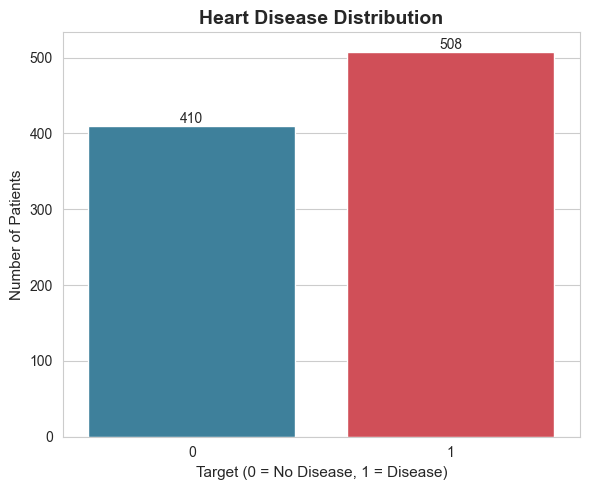

In [118]:
# Target variable distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="target", data=df, palette=PALETTE)
ax.set_title("Heart Disease Distribution")
ax.set_xlabel("Target (0 = No Disease, 1 = Disease)")
ax.set_ylabel("Number of Patients")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


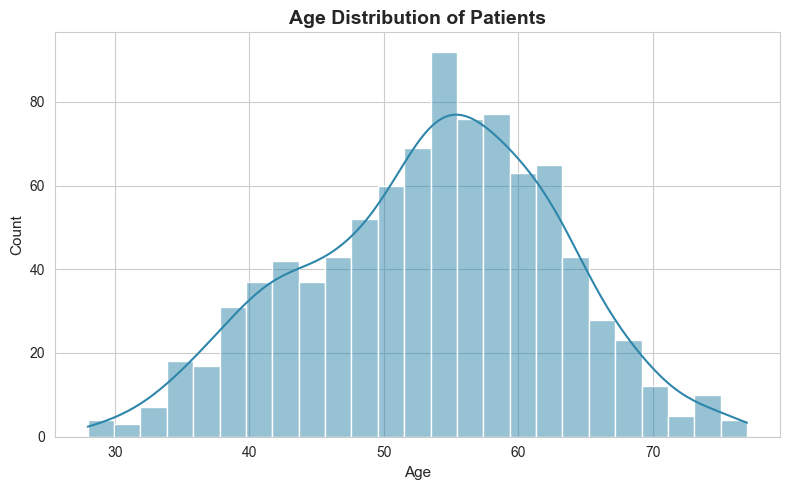

In [119]:
# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=25, kde=True, color=PALETTE[0])
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


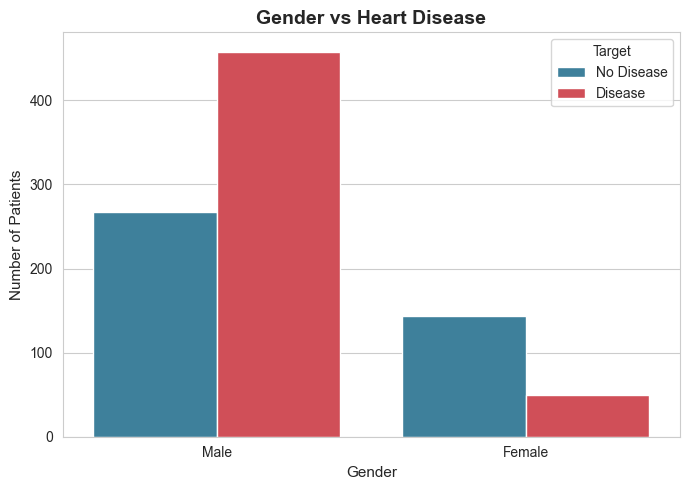

In [120]:
# Gender vs Target
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="sex", hue="target", data=df, palette=[PALETTE[0], PALETTE[1]])
ax.set_title("Gender vs Heart Disease")
ax.set_xlabel("Gender")
ax.set_ylabel("Number of Patients")
ax.legend(title="Target", labels=["No Disease", "Disease"])
plt.tight_layout()
plt.show()


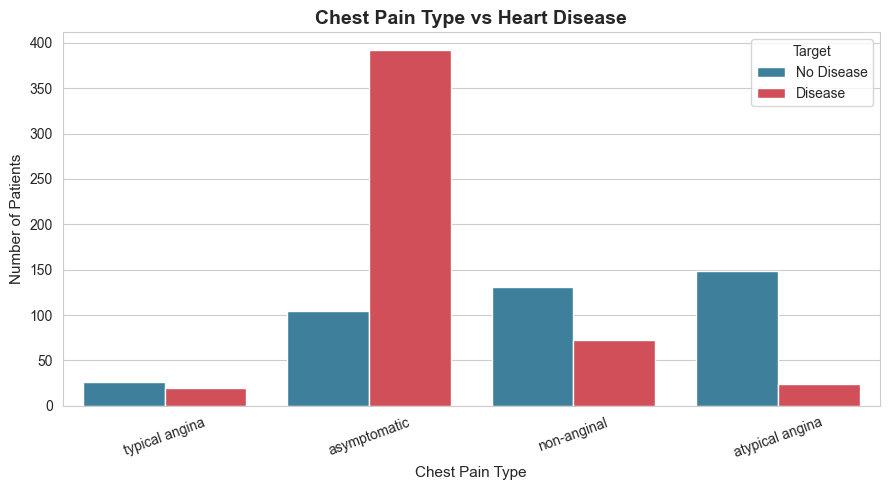

In [121]:
# Chest Pain Type vs Target
plt.figure(figsize=(9, 5))
ax = sns.countplot(x="cp", hue="target", data=df, palette=[PALETTE[0], PALETTE[1]])
ax.set_title("Chest Pain Type vs Heart Disease")
ax.set_xlabel("Chest Pain Type")
ax.set_ylabel("Number of Patients")
ax.legend(title="Target", labels=["No Disease", "Disease"])
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


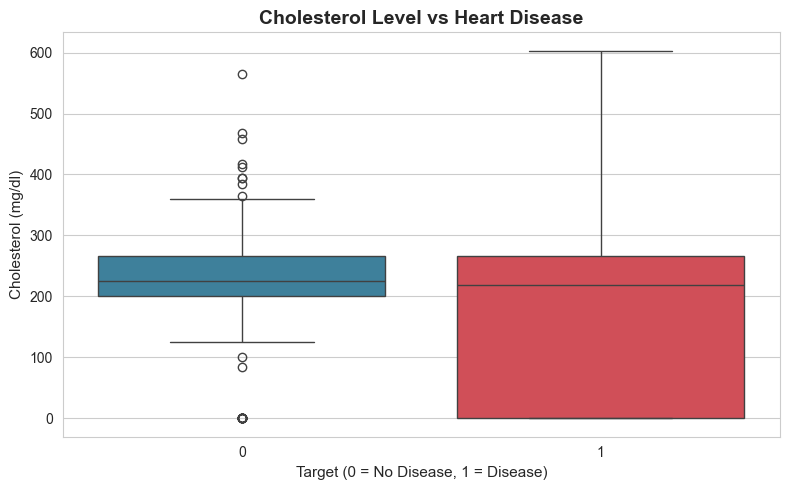

In [122]:
# Cholesterol vs Target
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="chol", data=df, palette=[PALETTE[0], PALETTE[1]])
plt.title("Cholesterol Level vs Heart Disease")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Cholesterol (mg/dl)")
plt.tight_layout()
plt.show()


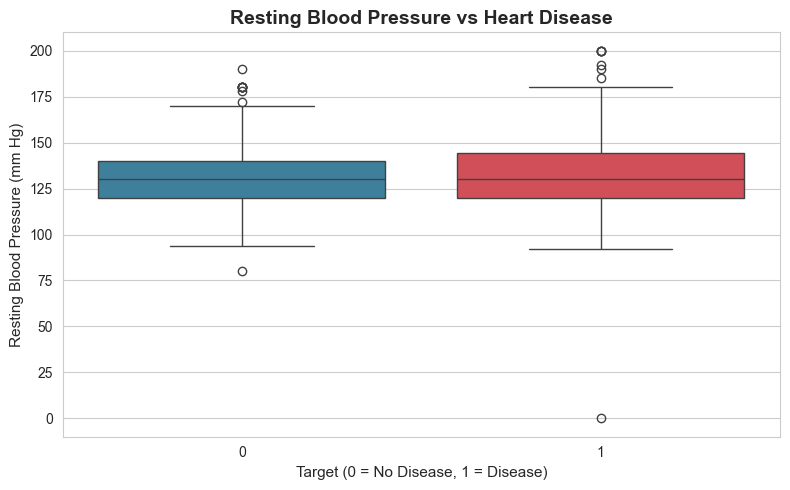

In [123]:
# Resting Blood Pressure vs Target
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="trestbps", data=df, palette=[PALETTE[0], PALETTE[1]])
plt.title("Resting Blood Pressure vs Heart Disease")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Resting Blood Pressure (mm Hg)")
plt.tight_layout()
plt.show()


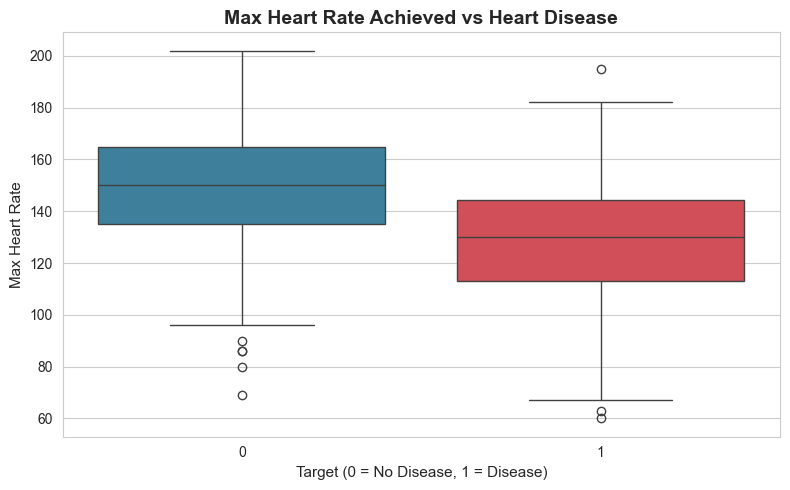

In [124]:
# Maximum Heart Rate Achieved vs Target
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="thalch", data=df, palette=[PALETTE[0], PALETTE[1]])
plt.title("Max Heart Rate Achieved vs Heart Disease")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Max Heart Rate")
plt.tight_layout()
plt.show()


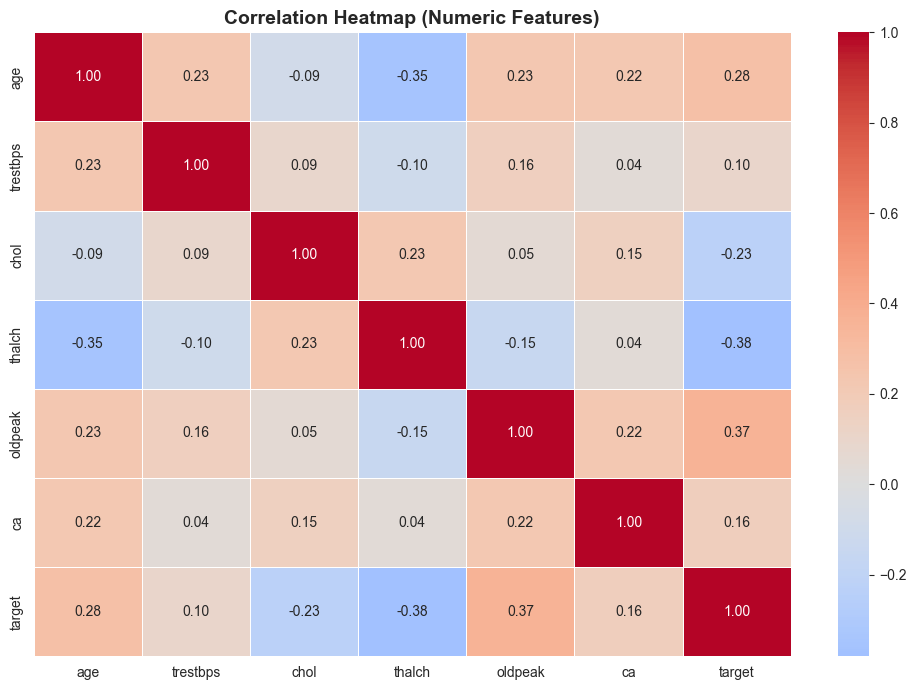

In [125]:
# Correlation heatmap for numeric features
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


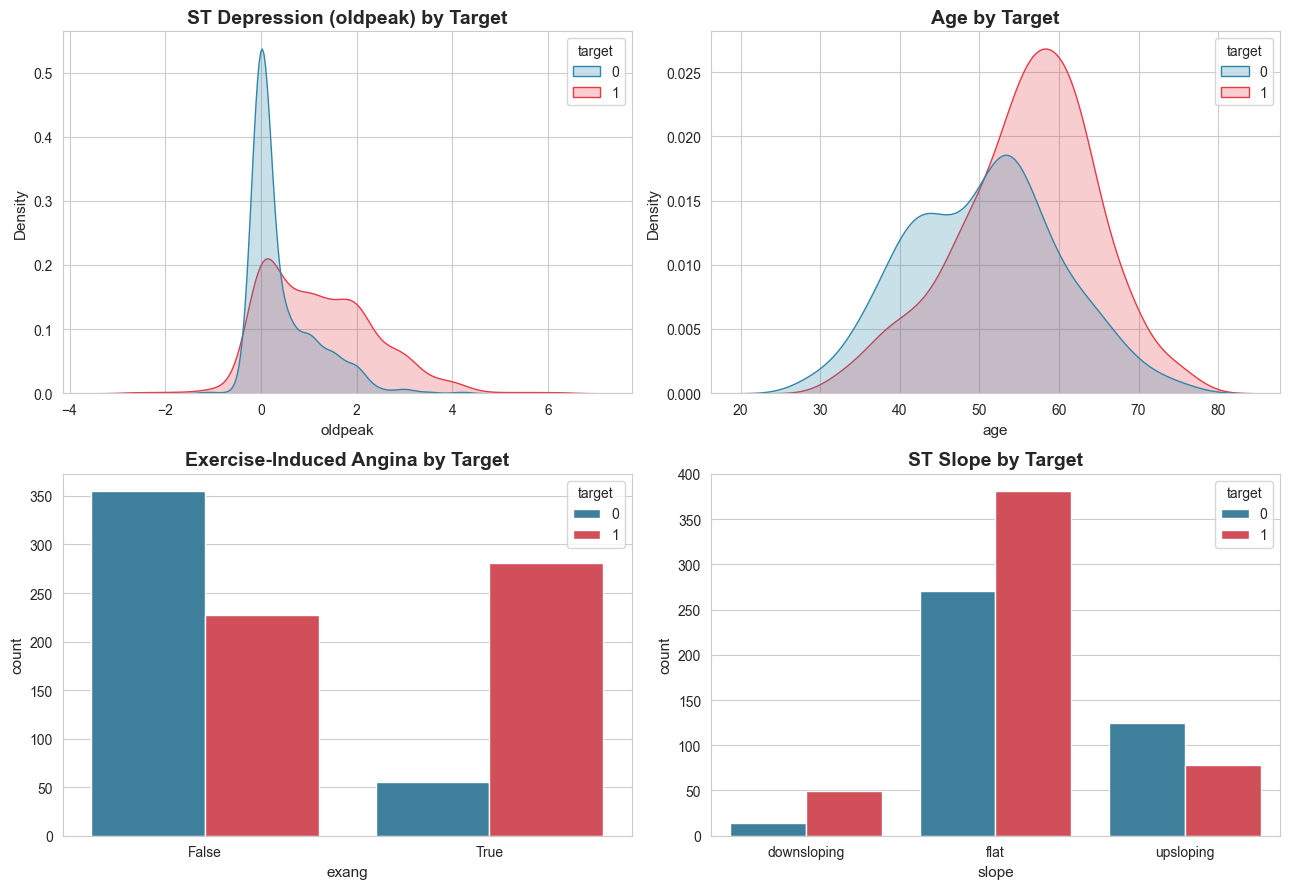

In [126]:
# Distribution of key numeric features split by target, side by side
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.kdeplot(data=df, x="oldpeak", hue="target", fill=True, palette=[PALETTE[0], PALETTE[1]], ax=axes[0, 0])
axes[0, 0].set_title("ST Depression (oldpeak) by Target")

sns.kdeplot(data=df, x="age", hue="target", fill=True, palette=[PALETTE[0], PALETTE[1]], ax=axes[0, 1])
axes[0, 1].set_title("Age by Target")

sns.countplot(x="exang", hue="target", data=df, palette=[PALETTE[0], PALETTE[1]], ax=axes[1, 0])
axes[1, 0].set_title("Exercise-Induced Angina by Target")

sns.countplot(x="slope", hue="target", data=df, palette=[PALETTE[0], PALETTE[1]], ax=axes[1, 1])
axes[1, 1].set_title("ST Slope by Target")

plt.tight_layout()
plt.show()


**EDA Insights:**
- The dataset is reasonably balanced between disease and no-disease cases.
- Patients with heart disease tend to skew slightly older and show a higher proportion of exercise-induced angina.
- Chest pain type "asymptomatic" is strongly associated with a positive diagnosis — somewhat counter-intuitive, but well documented in cardiology literature.
- `oldpeak` (ST depression) shows a visibly different distribution between the two target classes, suggesting it will be a useful predictive feature.


## Phase 5: Feature Engineering / Preprocessing

Steps:
1. Drop the `dataset` (site) column — not a patient health feature, just metadata about data collection.
2. Encode categorical columns into numeric form.
3. Split features (X) and target (y).
4. Train-test split with stratification (keeps class balance consistent).
5. Feature scaling — fit on training data only, then apply to both sets.


In [127]:
# Drop the site/source column — not a health feature
df_model = df.drop(columns=["dataset"])


In [128]:
# Identify categorical columns that need encoding
categorical_cols = ["sex", "cp", "restecg", "slope", "thal"]

# One-hot encode these categorical columns
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Convert boolean columns (fbs, exang) to integers (0/1)
df_model["fbs"] = df_model["fbs"].astype(int)
df_model["exang"] = df_model["exang"].astype(int)

df_model.head()


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,1,150.0,0,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,0,108.0,1,1.5,3.0,1,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,0,129.0,1,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,0,187.0,0,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,0,172.0,0,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False


In [129]:
# Separate features (X) and target (y)
X = df_model.drop(columns=["target"])
y = df_model["target"]

feature_columns = X.columns.tolist()
print(f"Number of features: {len(feature_columns)}")
feature_columns


Number of features: 18


['age',
 'trestbps',
 'chol',
 'fbs',
 'thalch',
 'exang',
 'oldpeak',
 'ca',
 'sex_Male',
 'cp_atypical angina',
 'cp_non-anginal',
 'cp_typical angina',
 'restecg_normal',
 'restecg_st-t abnormality',
 'slope_flat',
 'slope_upsloping',
 'thal_normal',
 'thal_reversable defect']

In [130]:
# Train-test split (80/20), stratified to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")


Training set: 734 rows
Test set: 184 rows


In [131]:
# Feature scaling — fit ONLY on training data, then transform both
# (prevents data leakage from the test set)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Phase 6: Model Training

Training three classification models: Logistic Regression, Random Forest, and SVM.

- Logistic Regression and SVM are trained on the **scaled** data (they are sensitive to feature scale).
- Random Forest is trained on the **unscaled** data (tree-based models don't need scaling), but we'll keep it consistent and use the scaled version here too for simplicity and comparability.


In [132]:
# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [133]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [134]:
# Support Vector Machine (probability=True so we can plot ROC curves later)
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Phase 7: Model Evaluation

Evaluating each model with accuracy, a confusion matrix, and a full classification report. Then comparing all three models using ROC curves and a precision/recall table.

In [135]:
# Helper function to evaluate a model and print a clean report
def evaluate_model(name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)

    acc = accuracy_score(y_test_data, y_pred)
    print(f"===== {name} =====")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test_data, y_pred))

    # Confusion matrix plot
    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"])
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"../images/confusion_matrix_{name.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()

    return acc, y_pred


===== Logistic Regression =====
Accuracy: 0.8261

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.76      0.79        82
           1       0.82      0.88      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.82       184



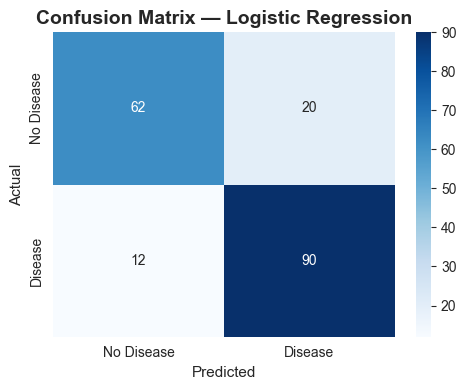

In [136]:
acc_log, pred_log = evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test)


In [137]:
display(Markdown(f"**Logistic Regression Accuracy: {acc_log * 100:.2f}%**"))


**Logistic Regression Accuracy: 82.61%**

===== Random Forest =====
Accuracy: 0.8478

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



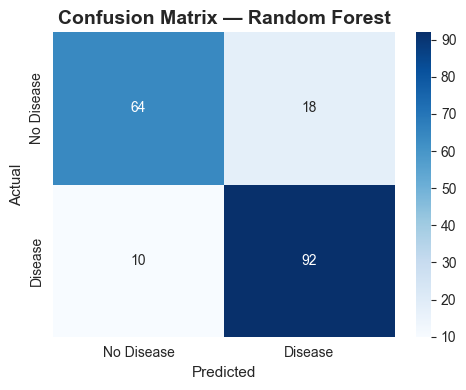

In [138]:
acc_rf, pred_rf = evaluate_model("Random Forest", rf_model, X_test_scaled, y_test)


In [139]:
display(Markdown(f"**Random Forest Accuracy: {acc_rf * 100:.2f}%**"))


**Random Forest Accuracy: 84.78%**

===== SVM =====
Accuracy: 0.8370

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        82
           1       0.82      0.90      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



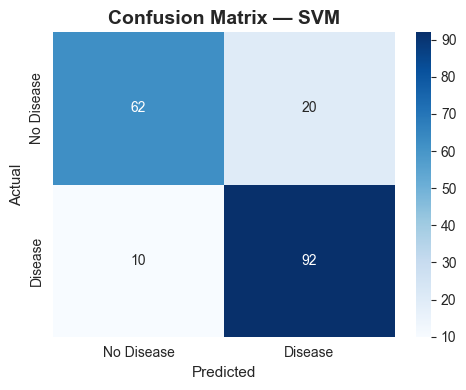

In [140]:
acc_svm, pred_svm = evaluate_model("SVM", svm_model, X_test_scaled, y_test)


In [141]:
display(Markdown(f"**SVM Accuracy: {acc_svm * 100:.2f}%**"))


**SVM Accuracy: 83.70%**

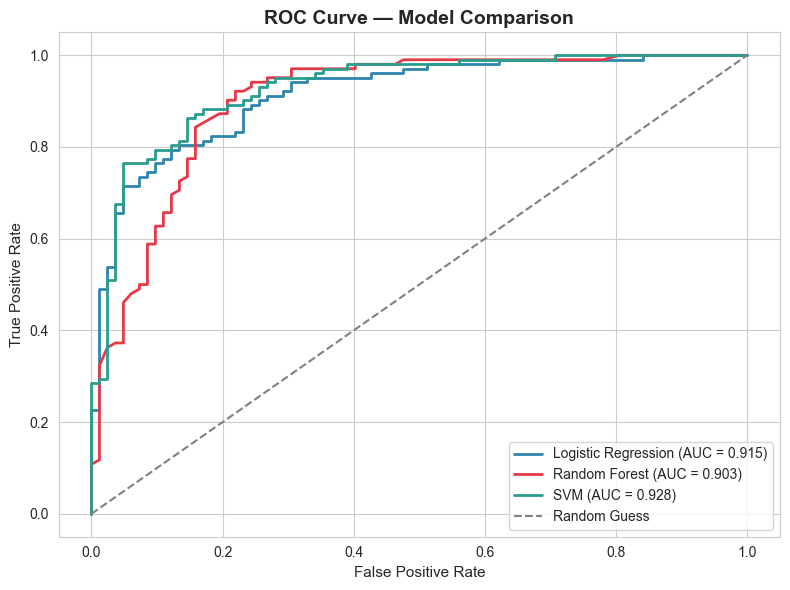

In [142]:
# ROC Curve comparison — all three models on one plot
plt.figure(figsize=(8, 6))

models_for_roc = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "SVM": svm_model
}

colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

for (name, model), color in zip(models_for_roc.items(), colors):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve — Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/roc_curve_comparison.png", dpi=150)
plt.show()


In [143]:
# Precision, Recall, F1-score comparison table
results = {
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_svm)
    ],
    "Precision": [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_svm)
    ],
    "Recall": [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_svm)
    ],
    "F1-Score": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_svm)
    ]
}

results_df = pd.DataFrame(results)

# Display a percentage-formatted version for easy reading
results_display = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_display[col] = (results_display[col] * 100).round(2).astype(str) + "%"

results_display


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,82.61%,81.82%,88.24%,84.91%
1,Random Forest,84.78%,83.64%,90.2%,86.79%
2,SVM,83.7%,82.14%,90.2%,85.98%


**Why Recall matters here:** In a medical context, a false negative (predicting "no disease" when the patient actually has it) is more dangerous than a false positive. So alongside overall accuracy, we pay close attention to **Recall** — a model that catches more true disease cases is often preferable, even at a small accuracy cost.

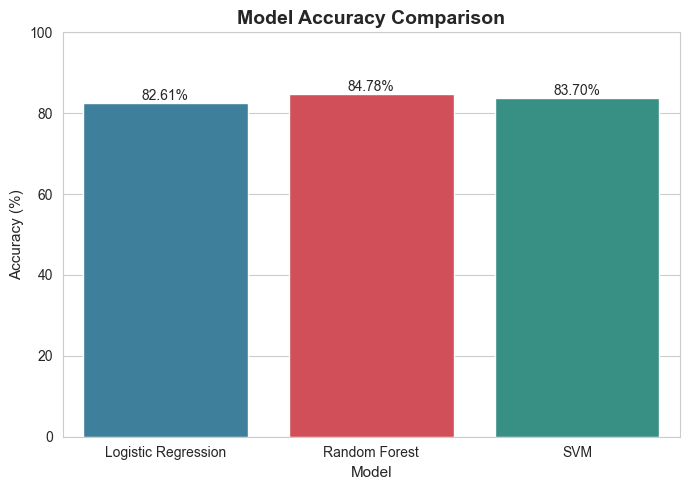

In [144]:
# Accuracy comparison bar chart (values shown as percentages)
results_df["Accuracy_pct"] = results_df["Accuracy"] * 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(x="Model", y="Accuracy_pct", data=results_df, palette=PALETTE[:3])
ax.set_title("Model Accuracy Comparison")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")
plt.tight_layout()
plt.savefig("../images/accuracy_comparison.png", dpi=150)
plt.show()


## Phase 8: Model Selection & Saving

Selecting the best-performing model based on the comparison table above, then saving the model, the scaler, and the feature column list — all three are needed later for the Streamlit app to make correct predictions.


In [145]:
# Pick the best model automatically based on highest accuracy
# (You can override this manually if Recall or F1 matters more for your use case)
best_row = results_df.loc[results_df["Accuracy"].idxmax()]
best_model_name = best_row["Model"]
print(f"Best performing model: {best_model_name}")

model_lookup = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "SVM": svm_model
}
best_model = model_lookup[best_model_name]


Best performing model: Random Forest


In [146]:
# Save the best model
joblib.dump(best_model, "../models/best_model.pkl")

# Save all three models individually too, for reference/comparison later
joblib.dump(log_reg, "../models/logistic_regression_model.pkl")
joblib.dump(rf_model, "../models/random_forest_model.pkl")
joblib.dump(svm_model, "../models/svm_model.pkl")


['../models/svm_model.pkl']

In [147]:
# Save the scaler — required to transform new/incoming data the same way
joblib.dump(scaler, "../models/scaler.pkl")

# Save the exact feature column order — required so new input matches training format
joblib.dump(feature_columns, "../models/feature_columns.pkl")

print("Model, scaler, and feature columns saved successfully.")


Model, scaler, and feature columns saved successfully.


## Phase 9: Model Reload Check

Loading everything back from disk and testing with a sample input to confirm the saved files work correctly end-to-end — exactly how the Streamlit app will use them later.

In [148]:
# Reload the saved model, scaler, and feature columns
loaded_model = joblib.load("../models/best_model.pkl")
loaded_scaler = joblib.load("../models/scaler.pkl")
loaded_feature_columns = joblib.load("../models/feature_columns.pkl")

print("Reloaded successfully.")
print(f"Model expects {len(loaded_feature_columns)} features.")


Reloaded successfully.
Model expects 18 features.


In [149]:
# Test with one real sample from the test set
sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)[0]
probability = loaded_model.predict_proba(sample_scaled)[0][1]

actual = y_test.iloc[0]

print(f"Predicted: {'Disease' if prediction == 1 else 'No Disease'}")
print(f"Probability of Disease: {probability:.2%}")
print(f"Actual: {'Disease' if actual == 1 else 'No Disease'}")


Predicted: No Disease
Probability of Disease: 34.50%
Actual: Disease


## Summary

- Cleaned and prepared a 920-row, multi-site heart disease dataset.
- Explored the data through visual EDA — distributions, class balance, and feature relationships with the target.
- Trained and compared three models: 
Logistic Regression,
Random Forest, and
SVM
- Evaluated using Accuracy, Confusion Matrix, ROC-AUC, Precision, Recall, and F1-score — not accuracy alone, since this is a medical prediction task.
- Saved the best model, scaler, and feature list with `joblib` for reuse in the Streamlit app (next phase).

